# Polynomial Regression

## What Is Polynomial Regression?

Polynomial regression is, at its core, still linear regression. The only difference is that we **transform the input features** before fitting the model.

Instead of fitting a straight line:

$$y = \theta_0 + \theta_1 x$$

We allow the model to fit curves by including higher powers of $x$:

$$y = \theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3 + \cdots + \theta_d x^d$$

The model is **nonlinear in** $x$, but it is still **linear in the parameters** $\theta$. This is the key insight — because the relationship is linear in $\theta$, we can still solve it using exactly the same linear regression machinery (the Normal Equation, gradient descent, etc.).

## Why Do We Need It?

Many real-world relationships are not straight lines. Examples include:

- Growth curves (population, bacteria)
- Projectile motion (parabolic path)
- Diminishing returns in economics
- Temperature vs. reaction rate in chemistry

When the true relationship is curved, a straight line **underfits** the data — it is too rigid to capture the structure. Polynomial regression introduces curvature while keeping the simplicity of a linear model.

## Mathematical Formulation

Given a feature vector:

$$\mathbf{X} = \begin{bmatrix} x_1 \\ x_2 \\ x_3 \\ \vdots \end{bmatrix}$$

For degree $d = 2$, we transform it into an expanded feature matrix $\Phi(\mathbf{X})$:

$$\Phi(\mathbf{X}) = \begin{bmatrix} 1 & x_1 & x_1^2 \\ 1 & x_2 & x_2^2 \\ 1 & x_3 & x_3^2 \\ \vdots & \vdots & \vdots \end{bmatrix}$$

Each row now has three columns: the bias term, the original feature, and its square. We then solve the standard linear regression problem on this expanded matrix:

$$\mathbf{y} = \Phi(\mathbf{X})\theta$$

Using the Normal Equation:

$$\theta = (\Phi^T\Phi)^{-1}\Phi^T\mathbf{y}$$

This means polynomial regression is mathematically equivalent to running linear regression on an expanded feature space. No new algorithm is needed.

## The Multiple Features Case

When we have more than one input feature, the expansion becomes richer. For two features $x_1$ and $x_2$ with degree $d = 2$, the expanded feature set becomes:

$$1, \quad x_1, \quad x_2, \quad x_1^2, \quad x_2^2, \quad x_1 x_2$$

Notice the **interaction term** $x_1 x_2$. This term captures the combined effect of two features together — something a standard linear model cannot express. Polynomial regression automatically generates these interaction terms as part of the expansion.

This is powerful, but it also means the number of features grows rapidly with degree and dimensionality. This is discussed further below.

## When To Use Polynomial Regression

**Use it when:**

- A scatter plot of your data shows clear curvature
- Linear regression underfits (low training score)
- The underlying relationship is smooth but nonlinear
- You want an interpretable model that is still analytically solvable

**Avoid it when:**

- The data is extremely noisy — the model will chase noise
- The degree is too high — overfitting becomes severe
- The number of features is large — the feature explosion problem (see below)

## Bias–Variance Tradeoff and Overfitting

Polynomial regression makes the bias–variance tradeoff very visible. As the degree $d$ increases:

| Degree | Bias | Variance | Behavior |
|---|---|---|---|
| Too low | High | Low | Underfitting — model too rigid |
| Just right | Low | Low | Good generalization |
| Too high | Low | High | Overfitting — model too flexible |

At a very high degree, the model can pass through every training point almost perfectly, giving a training $R^2 \approx 1$. But on unseen test data, performance collapses — the model has memorized noise instead of learning the true pattern.

This is why **degree is a hyperparameter** that must be selected carefully, typically using cross-validation.

## Feature Explosion

Every time you increase the degree or add more input features, the number of expanded features grows rapidly. For $n$ input features and polynomial degree $d$, the number of terms in the expanded feature space grows as:

$$\binom{n + d}{d}$$

For example, with $n = 3$ features and degree $d = 10$, this produces hundreds of new features. This is called **feature explosion**.

Feature explosion creates two problems:

- The model becomes much more prone to overfitting
- Computation becomes expensive

This is why **Polynomial Regression combined with Ridge regularization** is a very common pattern in practice. The polynomial expansion gives the model the flexibility to fit curves, while Ridge penalizes large weights and prevents the model from overfitting the many new features.

## A Note on Feature Scaling

For pure polynomial regression without regularization, scaling is not strictly required — the Normal Equation will still find the correct solution.

However, if you combine polynomial features with any regularization (Ridge, Lasso, or Elastic Net), **scaling becomes essential**. Regularization penalizes large weights, but if features are on different scales, the penalty is applied unevenly — features with large numerical ranges are penalized more than they should be. Standardizing features first ensures the regularization is applied fairly across all of them.

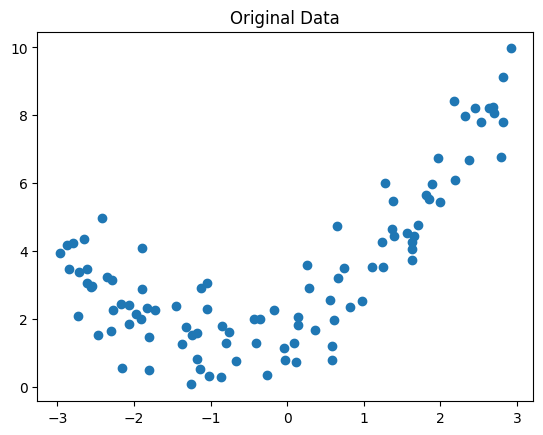

In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

plt.scatter(X, y)
plt.title("Original Data")
plt.show()

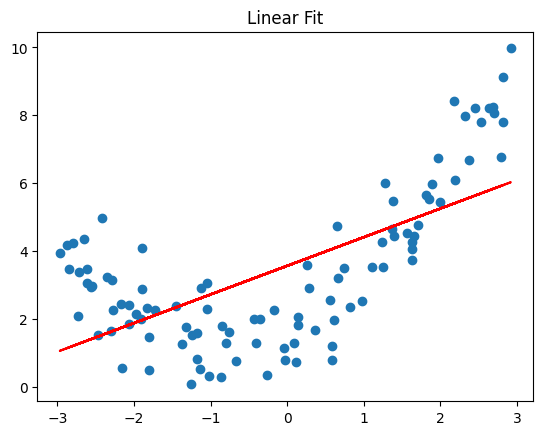

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

lin_model = LinearRegression()
lin_model.fit(X, y)

y_pred = lin_model.predict(X)

plt.scatter(X, y)
plt.plot(X, y_pred, color="red")
plt.title("Linear Fit")
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_model = make_pipeline(
    PolynomialFeatures(degree=3),
    LinearRegression()
)
poly_model.fit(X_train, y_train)

y_pred = poly_model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))

R2: 0.8555252772366515


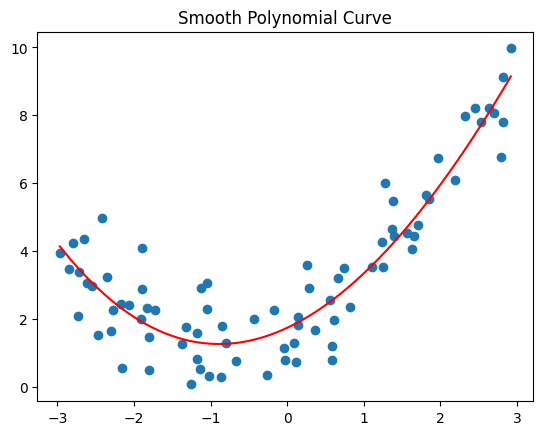

In [20]:
X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

y_range_pred = poly_model.predict(X_range)

plt.scatter(X_train, y_train)
plt.plot(X_range, y_range_pred, color="red")
plt.title("Smooth Polynomial Curve")
plt.show()